In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asmaalgarably","key":"4b651b680cc6bbc5d0c65c30667148e8"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip ravdess-emotional-speech-audio.zip -d ravdess_data

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:16<00:00, 26.6MB/s]

Archive:  ravdess-emotional-speech-audio.zip
  inflating: ravdess_data/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: ravdess_data/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: ravdess_data/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: ravdess_data/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: ravdess_data/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: ravdess_data/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: ravdess_data/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: ravdess_data/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: ravdess_data/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: ravdess_data/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: ravdess_data/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: ravdess_data/Actor_01/03-01-02-02-02-02-01.wav  
  inflating: ravdess_data/Actor_01/03-01-03-01-01-01-01

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = '/content/drive/MyDrive/Datasets/ravdess-emotional-speech-audio.zip'
extract_path = '/content/ravdess_data'

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Done!")
else:
    print("Dataset already extracted!")

Mounted at /content/drive
✅ Dataset already extracted!


In [15]:
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input


def extract_mfcc(file_path, n_mfcc=40):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    mfcc = np.mean(mfcc.T, axis=0)
    return mfcc

In [16]:
# RAVDESS emotion mapping
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

def load_data(data_path):
    X, y = [], []

    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('.wav'):
                # استخراج الـ emotion من اسم الملف
                emotion_code = file.split('-')[2]
                emotion = emotion_map.get(emotion_code)

                if emotion:
                    file_path = os.path.join(root, file)
                    mfcc = extract_mfcc(file_path)
                    X.append(mfcc)
                    y.append(emotion)

    return np.array(X), np.array(y)

# تحميل الداتا
print(" Loading data...")
X, y = load_data('/content/ravdess_data')
print(f" Loaded {len(X)} samples")
print(f"Emotions found: {np.unique(y)}")

 Loading data...
 Loaded 2880 samples
Emotions found: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [10]:
# تشفير الـ labels (happy → 2, sad → 3, ...)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)  # one-hot encoding

# تقسيم الداتا
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# CNN بتاخد شكل (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (2304, 40, 1) | Test: (576, 40, 1)


In [17]:
num_classes = len(le.classes_)

model = Sequential([
    # Block 1
    Input(shape=(40, 1)),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Block 2
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Block 3
    Conv1D(256, kernel_size=3, activation='relu'),
    Dropout(0.3),

    # Output
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 6, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,288 (1.23 MB)

 Trainable params: 321,288 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,          # وقف إذا ما تحسن 15 epoch
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # قلل الـ learning rate لنص
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.1393 - loss: 2.5659 - val_accuracy: 0.1337 - val_loss: 2.0518 - learning_rate: 0.0010
Epoch 2/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.1836 - loss: 2.0355 - val_accuracy: 0.1684 - val_loss: 2.0222 - learning_rate: 0.0010
Epoch 3/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1901 - loss: 2.0052 - val_accuracy: 0.2656 - val_loss: 1.9482 - learning_rate: 0.0010
Epoch 4/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2083 - loss: 1.9852 - val_accuracy: 0.2656 - val_loss: 1.9093 - learning_rate: 0.0010
Epoch 5/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2474 - loss: 1.9282 - val_accuracy: 0.3021 - val_loss: 1.8934 - learning_rate: 0.0010
Epoch 6/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2569 - loss: 1.9181 - val_accuracy: 0.2865 - val_loss: 1.8610 - learning_rate: 0.0010
Epoch 7/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2769 - loss: 1.8820 - 


 Test Accuracy: 94.44%


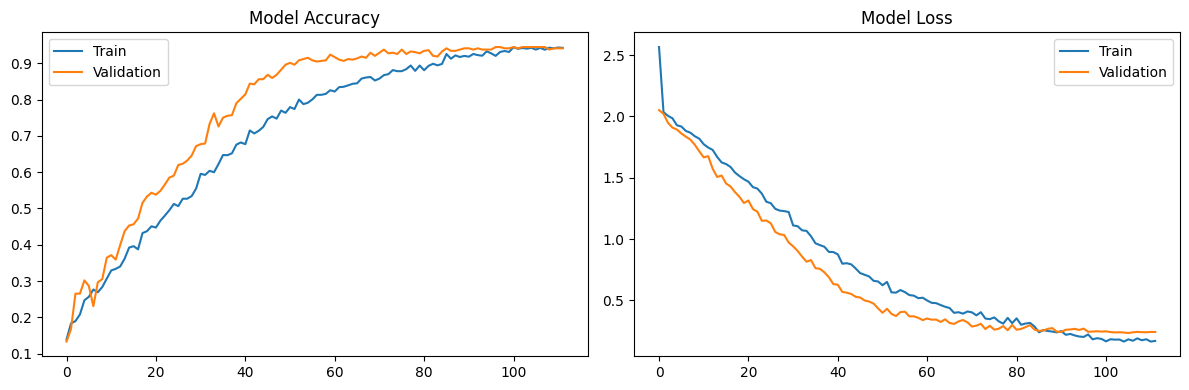

In [19]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Test Accuracy: {accuracy*100:.2f}%")

# رسم نتائج التدريب
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# حفظ الموديل
model.save('/content/drive/MyDrive/Models/speech_emotion_model.h5')

# حفظ الـ LabelEncoder
import joblib
joblib.dump(le, '/content/drive/MyDrive/Models/label_encoder.pkl')

print("Model saved to Google Drive!")

Model saved to Google Drive!
